#Actividad 13 Red neuronal de clasificación
Este código utiliza TensorFlow y el conjunto de datos MNIST para comenzar a trabajar con redes neuronales de clasificación.

El objetivo es que la computadora aprenda a reconocer números escritos a mano del 0 al 9.

El dataset MNIST contiene:

*  60,000 imágenes para entrenamiento.
*  10,000 imágenes para pruebas.
*  Imágenes de tamaño 28x28 píxeles en blanco y negro.













In [49]:
#Importación de librerías

import tensorflow as tf #tenserflow es una biblioteca principal para crear redes neuronales.
import tensorflow_datasets as tfds #permite descargar datasets ya preparados como MNIST.

##Carga del dataset
Se descarga el dataset MNIST.

In [50]:
datos, metadatos = tfds.load("mnist", as_supervised=True, with_info=True)

##Información del dataset
Muestra información importante como:
* Cantidad de imágenes.
* Tamaño de las imágenes.
* Número de clases.
* Tipo de datos.

In [51]:
metadatos

tfds.core.DatasetInfo(
    name='mnist',
    full_name='mnist/3.0.1',
    description="""
    The MNIST database of handwritten digits.
    """,
    homepage='http://yann.lecun.com/exdb/mnist/',
    data_dir='/root/tensorflow_datasets/mnist/3.0.1',
    file_format=tfrecord,
    download_size=11.06 MiB,
    dataset_size=21.00 MiB,
    features=FeaturesDict({
        'image': Image(shape=(28, 28, 1), dtype=uint8),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=10),
    }),
    supervised_keys=('image', 'label'),
    disable_shuffling=False,
    nondeterministic_order=False,
    splits={
        'test': <SplitInfo num_examples=10000, num_shards=1>,
        'train': <SplitInfo num_examples=60000, num_shards=1>,
    },
    citation="""@article{lecun2010mnist,
      title={MNIST handwritten digit database},
      author={LeCun, Yann and Cortes, Corinna and Burges, CJ},
      journal={ATT Labs [Online]. Available: http://yann.lecun.com/exdb/mnist},
      volume={2},
      year

In [52]:
datos_entrenamiento = datos["train"]
datos_pruebas = datos["test"]

In [53]:
nombres_clases = metadatos.features["label"].names

#Normalización de imágenes

Los valores originales de los píxeles van de:

0 → negro

255 → blanco

Para que la red neuronal aprenda mejor, los valores se convierten a un rango entre:

0 y 1

Esto mejora:

* Velocidad de entrenamiento.
* Precisión.
* Estabilidad de la red.

In [54]:
#Normalizacion
#0-255 1 bytw
#Transoformar 0-255 0-1 (00, 255-1, 127-.5)

def normalizar(imagenes, etiquetas):
    imagenes = tf.cast(imagenes, tf.float32)
    imagenes = imagenes / 255
    return imagenes, etiquetas

datos_entrenamiento = datos_entrenamiento.map(normalizar)
datos_pruebas = datos_pruebas.map(normalizar)

#Agregar en cache
datos_entrenamiento = datos_entrenamiento.cache()
datos_pruebas = datos_pruebas.cache()

#Mostrar las imagenes
Y por ultimo mostrar la imagenes del dataset

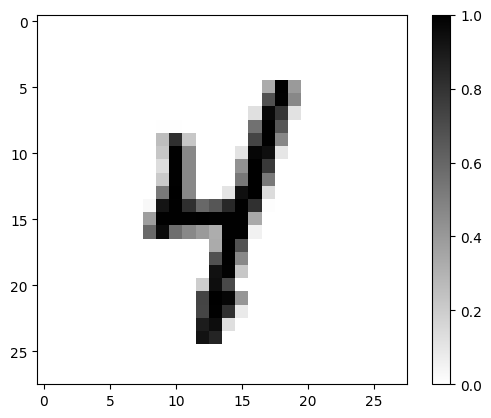

In [55]:

for imagen, etiqueta in datos_entrenamiento.take(1):
  break
import matplotlib.pyplot as plt

#mostrarlo en pantalla
plt.figure() #Crea una ventana para la imagen.
plt.imshow(imagen, cmap=plt.cm.binary) #Crea una ventana para la imagen y utiliza escala de colores blanco y negro.
plt.colorbar() #Muestra la intensidad de los píxeles.
plt.show() #Renderiza la imagen en pantalla.



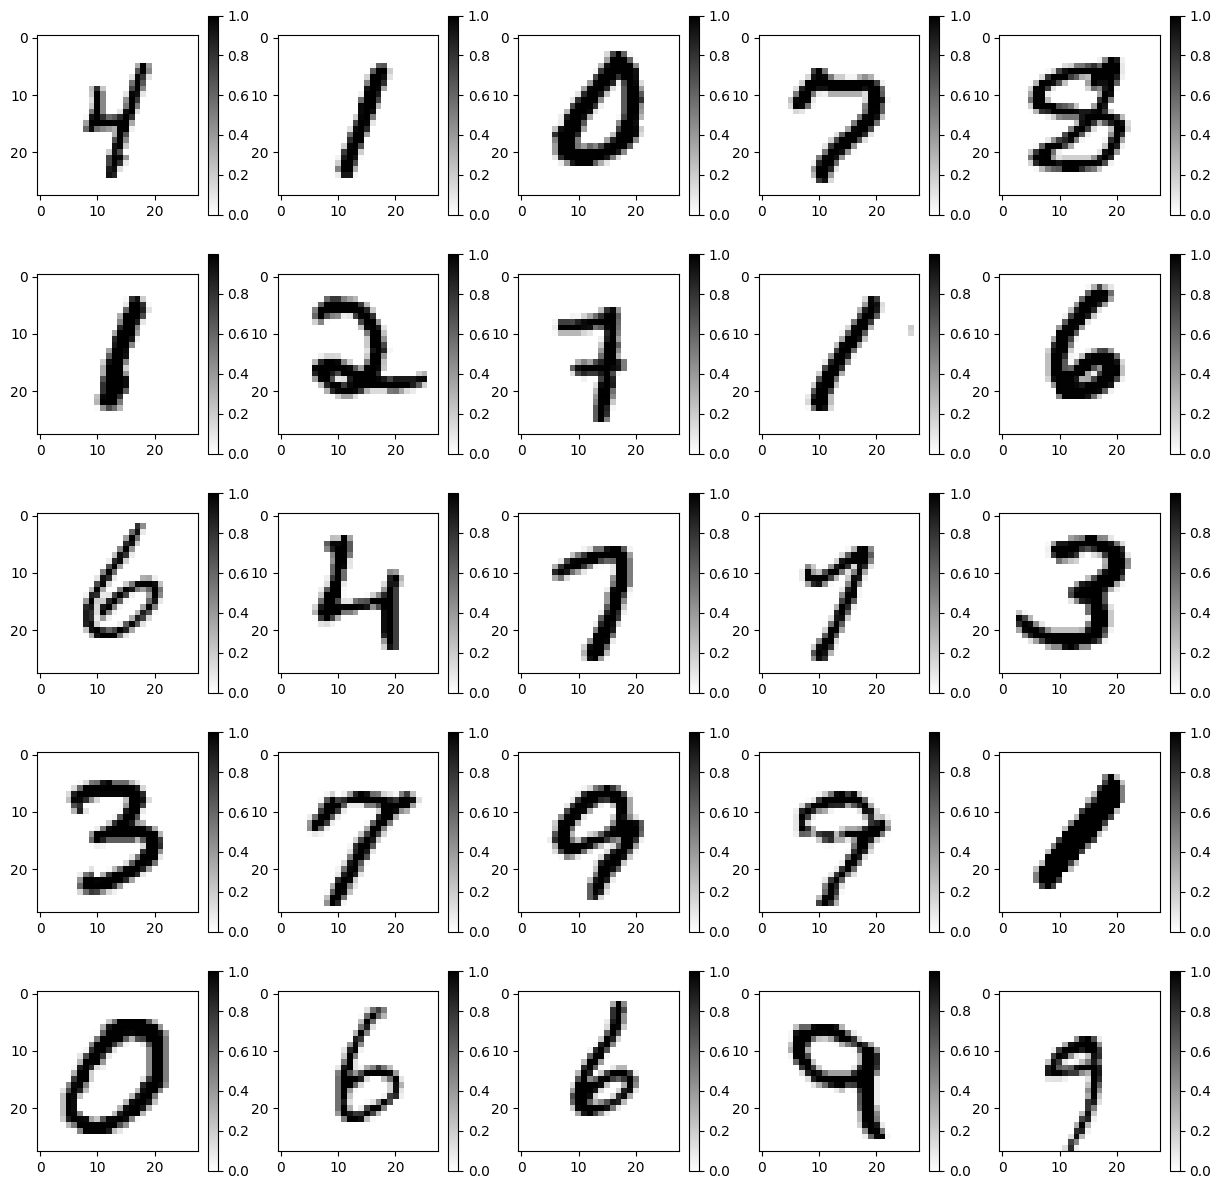

In [56]:
#Mostrar varias imágenes
#Este bloque muestra las primeras 25 imágenes del dataset.

plt.figure(figsize=(15,15)) #Define el tamaño de la ventana.
for i, (imagen, etiqueta) in enumerate(datos_entrenamiento.take(25)): #Obtiene 25 imágenes y permite obtener el índice y la imagen.

    #Mostrarlo en pantalla
    plt.subplot(5, 5, i+1) #Organiza las imágenes en una cuadrícula de 5 filas x 5 columnas
    plt.imshow(imagen, cmap=plt.cm.binary)
    plt.colorbar()

plt.show()
